# Watching a Matrix Deform Space

**This notebook is self-contained; it recaps what a transformation does before animating one.**

A single before-and-after picture hides what a transformation actually *does*. This notebook animates it: every vector on the unit circle, swept one at a time, with its image tracing out an ellipse. Watch which directions swing furthest and which barely move, that observation is the entire setup for **eigenvectors** two sections from now.

## Learning objectives

- Predict how the unit circle and a grid deform under a given matrix.
- Connect the ellipse's shape to the matrix's columns.
- Observe that some directions rotate a lot and some hardly at all.

## Background

The **unit circle** is the set of all vectors of length 1. A matrix $A$ sends each of them to $A\mathbf{v}$, and the collection of all those images is an **ellipse**. Recall that $A\mathbf{x}$ is a combination of $A$'s columns, and that the columns are where $\hat{\imath}$ and $\hat{\jmath}$ land, so the columns sit on the ellipse and tell you how it is stretched.

## This notebook covers

1. The unit circle and its image under $A$.
2. A vector swept around the circle, animated alongside its image.
3. Grid deformation for several choices of $A$.

**Prerequisites:** `U2-4_Transformations-1_MatrixAsMap`

**Dataset:** none, matrices are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## 1. The circle and the ellipse

Take every vector of length 1, together they trace the unit circle, and apply $A$ to all of them. The images form an ellipse. The two **columns of $A$** are the images of $\hat{\imath}$ and $\hat{\jmath}$, so they sit on that ellipse, and they show which way it has been stretched.

<IPython.core.display.Math object>

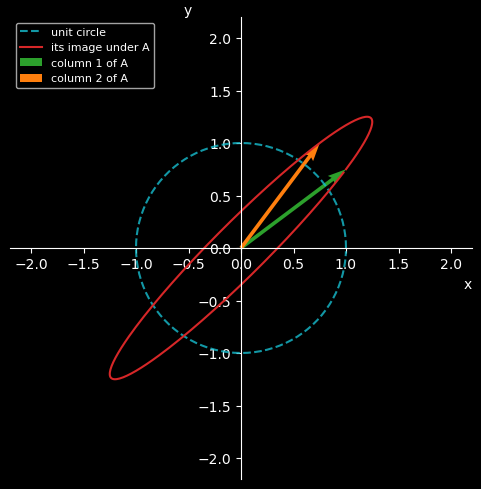

In [2]:
n_pts = 200
angles = np.linspace(0, 2 * np.pi, n_pts, endpoint=False)
circle = np.array([np.cos(angles), np.sin(angles)])     # 2 x n_pts, each column a unit vector

A = np.array([[1.0, 0.75],
              [0.75, 1.0]])
helpers.show(A, name="A")

ellipse = A @ circle

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(circle[0], circle[1], "--", color="tab:cyan", alpha=0.8, label="unit circle")
ax.plot(ellipse[0], ellipse[1], "-", color="tab:red", label="its image under A")
ax.quiver(0, 0, A[0, 0], A[1, 0], angles="xy", scale_units="xy", scale=1,
          color="tab:green", width=0.008, label="column 1 of A")
ax.quiver(0, 0, A[0, 1], A[1, 1], angles="xy", scale_units="xy", scale=1,
          color="tab:orange", width=0.008, label="column 2 of A")

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
plt.show()

## 2. The animation

Now sweep a single vector around the circle and watch its image move. This is the payoff a static board can't deliver: most directions get **rotated as well as stretched**, but keep an eye on the directions along the ellipse's long and short axes, those two barely turn at all. They only get longer or shorter.

Those are the **eigenvectors**, and finding them is what §2.6 is about. For now, just watch.

*(Press play below. The animation code is mechanics.)*

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(circle[0], circle[1], "--", color="tab:cyan", alpha=0.5)
ax.plot(ellipse[0], ellipse[1], "--", color="tab:red", alpha=0.5)
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal")
ax.set_title("one vector (cyan) and its image (red)", pad=20)

before, = ax.plot([], [], color="tab:cyan", lw=2.5)
after,  = ax.plot([], [], color="tab:red", lw=2.5)

n_frames = 36
step = n_pts // n_frames

def animate(i):
    v = circle[:, i * step]
    Av = A @ v
    before.set_data([0, v[0]], [0, v[1]])
    after.set_data([0, Av[0]], [0, Av[1]])
    return before, after

ani = FuncAnimation(fig, animate, frames=n_frames, blit=True, interval=100, repeat=True)
plt.close(fig)                      # keep the static figure from also rendering
HTML(ani.to_jshtml())

## 3. Deforming a grid

The circle shows what happens to length and direction; a **grid** shows what happens to space itself. Every line stays straight and evenly spaced, that is what makes a transformation *linear*, but the spacing and angles change.

Compare the four matrices below against the catalogue in the previous notebook.

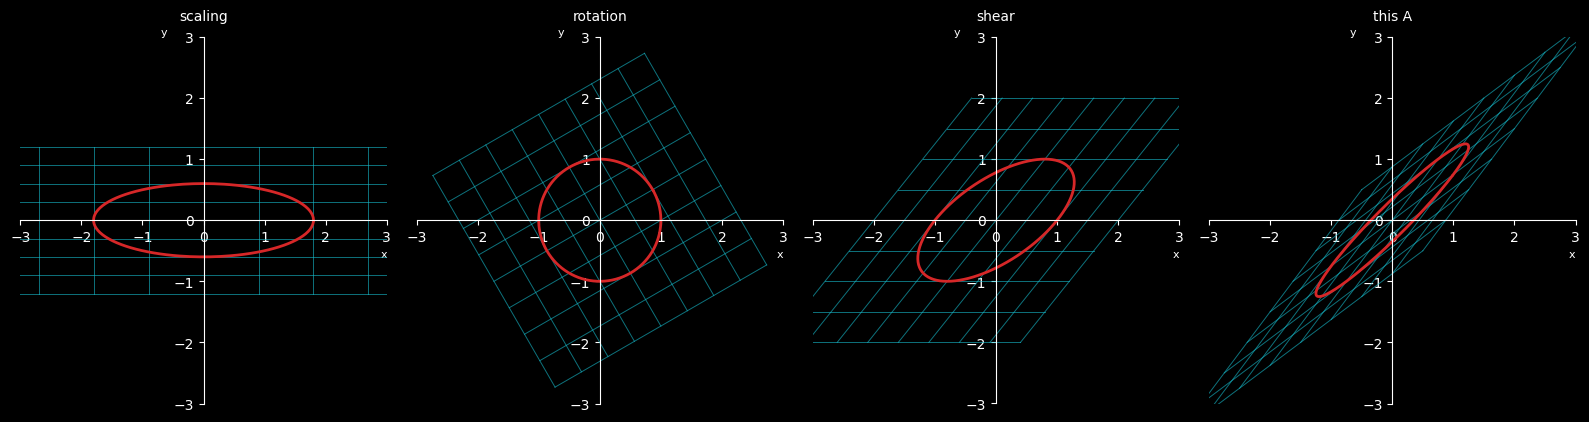

In [4]:
# build the horizontal and vertical lines of a grid, each as a 2 x pts array of points
def grid_lines(lo=-2, hi=2, n=9, pts=50):
    lines = []
    for c in np.linspace(lo, hi, n):
        t = np.linspace(lo, hi, pts)
        lines.append(np.array([t, np.full_like(t, c)]))    # horizontal
        lines.append(np.array([np.full_like(t, c), t]))    # vertical
    return lines

examples = [
    ("scaling",  np.array([[1.8, 0.0], [0.0, 0.6]])),
    ("rotation", np.array([[np.cos(np.radians(30)), -np.sin(np.radians(30))],
                           [np.sin(np.radians(30)),  np.cos(np.radians(30))]])),
    ("shear",    np.array([[1.0, 0.8], [0.0, 1.0]])),
    ("this A",   A),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, (name, M) in zip(axes, examples):
    for line in grid_lines():
        moved = M @ line
        ax.plot(moved[0], moved[1], color="tab:cyan", lw=0.7, alpha=0.6)
    moved_circle = M @ circle
    ax.plot(moved_circle[0], moved_circle[1], color="tab:red", lw=2)
    center_axes(ax); label_axes(ax)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
    ax.set_title(name, pad=12, fontsize=10)
plt.tight_layout()
plt.show()

## 4. Summary

- A matrix sends the **unit circle to an ellipse**; the columns of $A$ sit on that ellipse.
- Straight lines stay straight and evenly spaced, the defining feature of a *linear* transformation.
- Most directions are **rotated and stretched**, but a couple are only **stretched**. Those special directions are the **eigenvectors**, coming in §2.6.

Next: measuring how much a transformation stretches *area*, and what happens when that area hits zero (`U2-5_Determinants-1_AsArea`).